# Line movement: poll the odds and chart how prices move

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JacobiusMakes/parlayapi-notebooks/blob/main/03-line-movement.ipynb)

Odds are not static: prices drift as money and news arrive, and the drift itself is
signal (steam moves, reverse line movement, closing line value). This notebook
polls the ParlayAPI odds feed on a fixed interval, records every price it sees, and
charts the movement per bookmaker with matplotlib.

Works with no key (demo endpoint, 60 requests per hour, so keep the poll count
modest). A [free key](https://parlay-api.com/signup) raises the ceiling and adds books and markets.

Honest expectation-setting: over the couple of minutes this demo polls, lines often
do not move at all, especially hours before a game. The plumbing is the point; run
it longer (raise `POLLS` and `INTERVAL_SECONDS`) or near game time to see real
movement. Keyed users can also pull server-side history from
`GET /v1/sports/{sport}/line-movement` instead of polling.

In [1]:
# ---- Config: paste your API key between the quotes ----
# Get a free key at https://parlay-api.com/signup (free tier, no card required).
# Leave it empty to run against the keyless demo endpoint instead.
API_KEY = ""

import os
API_KEY = (API_KEY or os.environ.get("PARLAYAPI_KEY", "")).strip()
BASE_URL = "https://parlay-api.com"
SPORT = "baseball_mlb"  # also try: basketball_nba, americanfootball_nfl, icehockey_nhl, soccer_epl

if API_KEY:
    print("API key set: using the full keyed endpoints.")
else:
    print("No API key set: falling back to the keyless demo endpoint.")
    print("The demo serves the first 5 events per sport, moneyline (h2h) only,")
    print("capped at 60 requests per hour. Paste a free key above for all events,")
    print("all 30+ books, and every market:", "https://parlay-api.com/signup")

No API key set: falling back to the keyless demo endpoint.
The demo serves the first 5 events per sport, moneyline (h2h) only,
capped at 60 requests per hour. Paste a free key above for all events,
all 30+ books, and every market: https://parlay-api.com/signup


In [2]:
import requests

def fetch_odds(sport=None, markets="h2h,spreads,totals", odds_format="american"):
    """Fetch current odds as a list of event dicts.

    Keyed:   GET /v1/sports/{sport}/odds returns a bare JSON array of events
             (the-odds-api compatible shape).
    Keyless: GET /v1/try/{sport}/odds returns a demo envelope instead: the
             events are nested under the "events" key, next to demo metadata
             like demo_message and demo_remaining_hour. The two shapes are
             NOT the same at the top level, so we unwrap here.

    Each event: id, home_team, away_team, commence_time, and
    bookmakers[] -> markets[] -> outcomes[] with American prices by default.
    """
    sport = sport or SPORT
    if API_KEY:
        resp = requests.get(
            f"{BASE_URL}/v1/sports/{sport}/odds",
            params={"markets": markets, "oddsFormat": odds_format},
            headers={"X-API-Key": API_KEY},
            timeout=30,
        )
        resp.raise_for_status()
        return resp.json()
    resp = requests.get(f"{BASE_URL}/v1/try/{sport}/odds", timeout=30)
    resp.raise_for_status()
    payload = resp.json()
    # Demo envelope: {"demo": true, "demo_message": "...", "events": [...]}
    return payload.get("events", [])

## Poll on an interval

Each poll fetches the current board and appends one row per (bookmaker, outcome)
for the first event on the slate. Keep `POLLS * INTERVAL_SECONDS` small when
keyless: the demo endpoint allows 60 requests per hour.

In [3]:
import time
import pandas as pd
from datetime import datetime, timezone

POLLS = 5
INTERVAL_SECONDS = 12

records = []
event_id = None
event_label = None

for poll in range(1, POLLS + 1):
    ts = datetime.now(timezone.utc)
    try:
        events = fetch_odds(markets="h2h")
    except Exception as exc:
        print(f"poll {poll}: fetch failed ({exc}); skipping")
        events = []
    if events and event_id is None:
        event_id = events[0]["id"]
        event_label = f"{events[0]['away_team']} at {events[0]['home_team']}"
        print(f"Tracking: {event_label} (starts {events[0]['commence_time']})")
    target = next((e for e in events if e["id"] == event_id), None)
    if target is None:
        print(f"poll {poll}: tracked event not on the board")
    else:
        for bm in target.get("bookmakers", []):
            for mkt in bm.get("markets", []):
                if mkt["key"] != "h2h":
                    continue
                for out in mkt.get("outcomes", []):
                    records.append({"poll": poll, "time_utc": ts,
                                    "bookmaker": bm["key"], "outcome": out["name"],
                                    "price": out["price"]})
        print(f"poll {poll}/{POLLS} at {ts:%H:%M:%S}Z: "
              f"{len(target.get('bookmakers', []))} books recorded")
    if poll < POLLS:
        time.sleep(INTERVAL_SECONDS)

history = pd.DataFrame(records)
print(f"\ncollected {len(history)} price observations")

Tracking: Colorado Rockies at Atlanta Braves (starts 2026-08-29T20:10:00Z)
poll 1/5 at 13:25:26Z: 14 books recorded


poll 2/5 at 13:25:41Z: 14 books recorded


poll 3/5 at 13:25:54Z: 14 books recorded


poll 4/5 at 13:26:10Z: 14 books recorded


poll 5/5 at 13:26:27Z: 14 books recorded

collected 135 price observations


## The movement table

Before any chart, look at the raw numbers: first and last observed price per book
and side, and the delta in American cents. (A price that goes from -110 to -115
moved 5 cents against you.)

In [4]:
if history.empty:
    print("No data collected; nothing to summarize.")
else:
    summary = (history.sort_values("poll")
               .groupby(["bookmaker", "outcome"])["price"]
               .agg(first_price="first", last_price="last", observations="count")
               .reset_index())
    summary["moved_cents"] = summary["last_price"] - summary["first_price"]
    display(summary)
    if (summary["moved_cents"] == 0).all():
        print("No movement during this window, which is common over a couple of")
        print("minutes. Raise POLLS / INTERVAL_SECONDS or run closer to game time.")

,bookmaker,outcome,first_price,last_price,observations,moved_cents
0,bet365,Atlanta Braves,-220,-220,5,0
1,bet365,Colorado Rockies,200,200,5,0
2,betmgm,Atlanta Braves,-235,-235,5,0
3,betmgm,Colorado Rockies,190,190,5,0
4,betrivers,Atlanta Braves,-225,-225,5,0
5,betrivers,Colorado Rockies,188,188,5,0
6,bovada,Atlanta Braves,-225,-225,5,0
7,bovada,Colorado Rockies,185,185,5,0
8,caesars,Atlanta Braves,-220,-220,5,0
9,caesars,Colorado Rockies,200,200,5,0


No movement during this window, which is common over a couple of
minutes. Raise POLLS / INTERVAL_SECONDS or run closer to game time.


## Chart it

One panel per side of the market, one line per bookmaker, steps because a price
holds until it changes. Matplotlib only, default color cycle, single y axis. To
keep the chart readable the plot caps itself at the 6 most-observed books; raise
`BOOKS_TO_PLOT` to see them all (the summary table above already does).

plotting 6 of 14 books; raise BOOKS_TO_PLOT for more


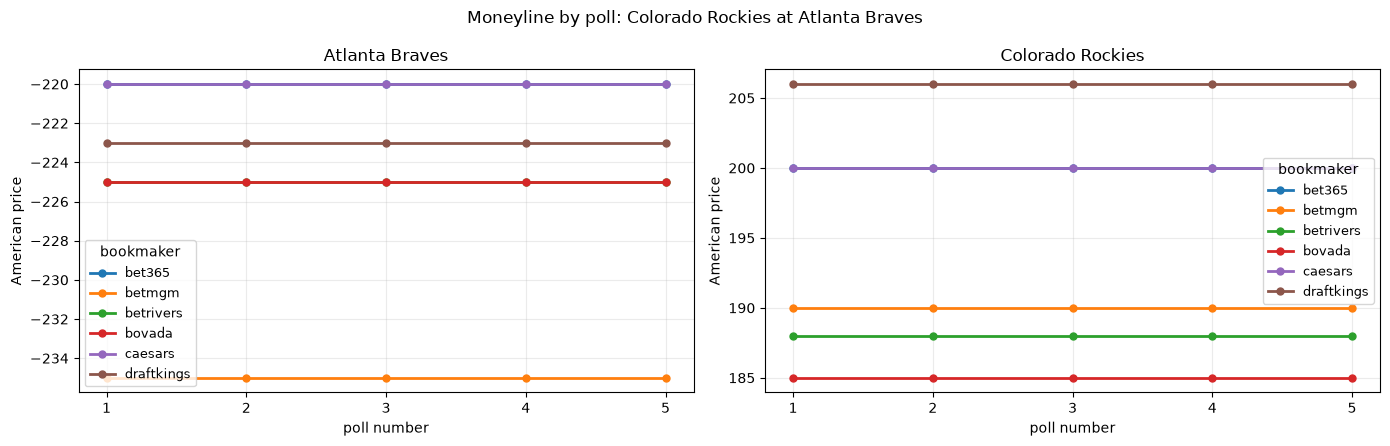

In [5]:
import matplotlib.pyplot as plt

if history.empty:
    print("Nothing to plot.")
else:
    BOOKS_TO_PLOT = 6
    top_books = (history.groupby("bookmaker")["price"].count()
                 .sort_values(ascending=False).head(BOOKS_TO_PLOT).index)
    plotted = history[history["bookmaker"].isin(top_books)]
    n_books = history["bookmaker"].nunique()
    if n_books > BOOKS_TO_PLOT:
        print(f"plotting {BOOKS_TO_PLOT} of {n_books} books; raise BOOKS_TO_PLOT for more")
    outcomes = list(plotted["outcome"].unique())
    fig, axes = plt.subplots(1, len(outcomes), figsize=(7 * len(outcomes), 4.5),
                             sharey=False, squeeze=False)
    for ax, outcome in zip(axes[0], outcomes):
        side = plotted[plotted["outcome"] == outcome]
        for book, grp in side.groupby("bookmaker"):
            grp = grp.sort_values("poll")
            ax.plot(grp["poll"], grp["price"], drawstyle="steps-post",
                    linewidth=2, marker="o", markersize=5, label=book)
        ax.set_title(outcome)
        ax.set_xlabel("poll number")
        ax.set_ylabel("American price")
        ax.set_xticks(sorted(side["poll"].unique()))
        ax.grid(True, alpha=0.25)
        ax.legend(title="bookmaker", fontsize=9)
    fig.suptitle(f"Moneyline by poll: {event_label}" if event_label else "Moneyline by poll")
    plt.tight_layout()
    plt.show()

## Where to take this

- Persist every poll to CSV or a database (notebook 01 has the flattener) and you
  are building your own line-movement archive.
- Compare your entry price to the last pre-game price you observed: that is
  closing line value, the subject of notebook 04.
- Keyed plans can skip client-side polling: `GET /v1/sports/{sport}/line-movement`
  serves movement history, and WebSocket / SSE streaming exists on the Business
  tier and up (see [parlay-api.com/pricing](https://parlay-api.com/pricing)).

---

**More ParlayAPI resources**

- Docs: [parlay-api.com/docs](https://parlay-api.com/docs)
- Free API key (no card): [parlay-api.com/signup](https://parlay-api.com/signup)
- Browser calculators the math here matches: [no-vig](https://parlay-api.com/tools/no-vig-calculator), [parlay](https://parlay-api.com/tools/parlay-calculator), [EV](https://parlay-api.com/tools/ev-calculator)
- The rest of this series: [github.com/JacobiusMakes/parlayapi-notebooks](https://github.com/JacobiusMakes/parlayapi-notebooks)

These notebooks are for research and education. Nothing here is betting advice.